Data Inspection

In [6]:
from datasets import load_dataset

ds = load_dataset(
    "criteo/criteo-uplift",
    split="train"
)

df = ds.to_pandas()

In [7]:
df["treatment"].value_counts()

treatment
1    11882655
0     2096937
Name: count, dtype: int64

In [8]:
df = df.sample(
    n=200000,
    random_state=42
).reset_index(drop=True)

In [9]:
df["treatment"].value_counts(normalize=True)

treatment
1    0.849675
0    0.150325
Name: proportion, dtype: float64

Exploratory Data Analysis

In [10]:
# Overall conversion rate
print("Overall conversion rate:")
print(df["conversion"].mean())

print()

# Overall visit rate
print("Overall visit rate:")
print(df["visit"].mean())

Overall conversion rate:
0.003215

Overall visit rate:
0.047575


In [11]:
# Conversion rate by treatment group
conversion_rates = (
    df.groupby("treatment")["conversion"]
      .mean()
)

print(conversion_rates)

treatment
0    0.001796
1    0.003466
Name: conversion, dtype: float64


In [12]:
# Visit rate by treatment group
visit_rates = (
    df.groupby("treatment")["visit"]
      .mean()
)

print(visit_rates)

treatment
0    0.038849
1    0.049119
Name: visit, dtype: float64


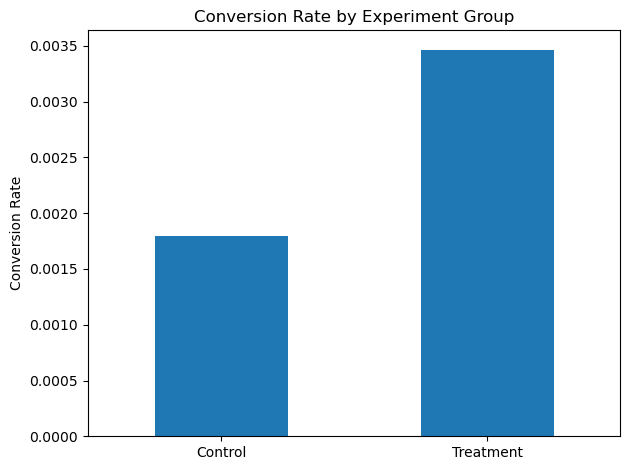

In [14]:
import matplotlib.pyplot as plt

conversion_rates.index = ["Control", "Treatment"]

conversion_rates.plot(kind="bar")

plt.title("Conversion Rate by Experiment Group")
plt.xlabel("")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
# Estimating the Treatment Effect

# Conversion rates
control_rate = df.loc[df["treatment"] == 0, "conversion"].mean()
treatment_rate = df.loc[df["treatment"] == 1, "conversion"].mean()

# Absolute uplift (Average Treatment Effect)
uplift = treatment_rate - control_rate

# Relative uplift
relative_uplift = uplift / control_rate

print(f"Control conversion rate:   {control_rate:.6f}")
print(f"Treatment conversion rate: {treatment_rate:.6f}")
print(f"\nAbsolute uplift: {uplift:.6f}")
print(f"Relative uplift: {relative_uplift:.2%}")

Control conversion rate:   0.001796
Treatment conversion rate: 0.003466

Absolute uplift: 0.001670
Relative uplift: 92.97%


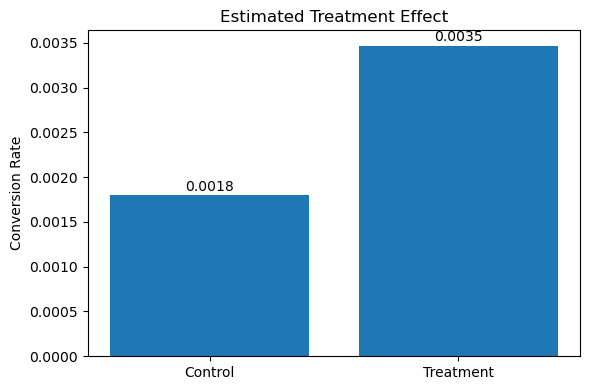

In [16]:
import matplotlib.pyplot as plt

rates = [control_rate, treatment_rate]
labels = ["Control", "Treatment"]

plt.figure(figsize=(6,4))
plt.bar(labels, rates)

for i, v in enumerate(rates):
    plt.text(i, v + 0.00005, f"{v:.4f}", ha="center")

plt.ylabel("Conversion Rate")
plt.title("Estimated Treatment Effect")

plt.tight_layout()
plt.show()

Statistical Analysis

In [17]:
import numpy as np

# Group data
control = df.loc[df["treatment"] == 0, "conversion"]
treatment = df.loc[df["treatment"] == 1, "conversion"]

# Sample sizes
n_control = len(control)
n_treatment = len(treatment)

# Conversion rates
p_control = control.mean()
p_treatment = treatment.mean()

# Treatment effect
uplift = p_treatment - p_control

# Standard error for difference in proportions
se = np.sqrt(
    (p_treatment * (1 - p_treatment) / n_treatment) +
    (p_control * (1 - p_control) / n_control)
)

# 95% confidence interval
lower = uplift - 1.96 * se
upper = uplift + 1.96 * se

print(f"Control conversion rate:   {p_control:.6f}")
print(f"Treatment conversion rate: {p_treatment:.6f}")
print(f"Estimated uplift:          {uplift:.6f}")
print(f"Standard error:            {se:.6f}")
print(f"95% CI: [{lower:.6f}, {upper:.6f}]")

Control conversion rate:   0.001796
Treatment conversion rate: 0.003466
Estimated uplift:          0.001670
Standard error:            0.000283
95% CI: [0.001116, 0.002224]


In [19]:
from statsmodels.stats.proportion import proportions_ztest

# Number of conversions
conversions = [
    treatment.sum(),
    control.sum()
]

# Number of users
sample_sizes = [
    len(treatment),
    len(control)
]

# Two-sided z-test
z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=sample_sizes,
    alternative="two-sided"
)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.10f}")

Z-statistic: 4.7148
P-value: 0.0000024196


In [20]:
# Additional conversions per 1,000 users
additional_per_1000 = uplift * 1000

# Additional conversions per 1,000,000 users
additional_per_million = uplift * 1_000_000

print(f"Additional conversions per 1,000 users: {additional_per_1000:.2f}")
print(f"Additional conversions per 1,000,000 users: {additional_per_million:.0f}")

Additional conversions per 1,000 users: 1.67
Additional conversions per 1,000,000 users: 1670


In [21]:
print("Experiment Summary")
print("------------------")
print(f"Control conversion rate:   {p_control:.6f}")
print(f"Treatment conversion rate: {p_treatment:.6f}")
print(f"Estimated uplift:          {uplift:.6f}")
print(f"95% CI:                    [{lower:.6f}, {upper:.6f}]")
print(f"P-value:                   {p_value:.10f}")
print(f"Additional conversions per 1M users: {additional_per_million:.0f}")

Experiment Summary
------------------
Control conversion rate:   0.001796
Treatment conversion rate: 0.003466
Estimated uplift:          0.001670
95% CI:                    [0.001116, 0.002224]
P-value:                   0.0000024196
Additional conversions per 1M users: 1670


In [22]:
# Example business assumptions
revenue_per_conversion = 100    # dollars
cost_per_ad = 0.05              # dollars

# Expected business impact
extra_conversions = additional_per_million

extra_revenue = extra_conversions * revenue_per_conversion
ad_cost = 1_000_000 * cost_per_ad
profit = extra_revenue - ad_cost

print(f"Additional revenue: ${extra_revenue:,.0f}")
print(f"Advertising cost:   ${ad_cost:,.0f}")
print(f"Estimated profit:   ${profit:,.0f}")

Additional revenue: $166,992
Advertising cost:   $50,000
Estimated profit:   $116,992


In [23]:
break_even_value = ad_cost / additional_per_million

print(f"Break-even value per conversion: ${break_even_value:.2f}")

Break-even value per conversion: $29.94


In [24]:
# Lower, expected, and upper additional conversions per 1M users
lower_conversions = lower * 1_000_000
expected_conversions = uplift * 1_000_000
upper_conversions = upper * 1_000_000

# Business assumptions
revenue_per_conversion = 100
cost_per_ad = 0.05

ad_cost = 1_000_000 * cost_per_ad

# Profits
lower_profit = lower_conversions * revenue_per_conversion - ad_cost
expected_profit = expected_conversions * revenue_per_conversion - ad_cost
upper_profit = upper_conversions * revenue_per_conversion - ad_cost

print(f"Worst-case profit (95% CI lower): ${lower_profit:,.0f}")
print(f"Expected profit:               ${expected_profit:,.0f}")
print(f"Best-case profit (95% CI upper): ${upper_profit:,.0f}")

Worst-case profit (95% CI lower): $61,569
Expected profit:               $116,992
Best-case profit (95% CI upper): $172,415


Synthetic Non-Randomized Data

In [45]:
observational_df = df.copy()

score = (
    0.15 * observational_df["f0"] +
    0.10 * observational_df["f1"]
)

score = score - score.mean()

prob = 1 / (1 + np.exp(-score))

np.random.seed(42)

observational_df["treatment"] = np.random.binomial(1, prob)

observational_df["treatment"].value_counts(normalize=True)

treatment
1    0.50105
0    0.49895
Name: proportion, dtype: float64

In [46]:
# Naive treatment effect in the observational data

obs_control = observational_df.loc[
    observational_df["treatment"] == 0,
    "conversion"
].mean()

obs_treatment = observational_df.loc[
    observational_df["treatment"] == 1,
    "conversion"
].mean()

obs_uplift = obs_treatment - obs_control

print(f"Control conversion rate:   {obs_control:.6f}")
print(f"Treatment conversion rate: {obs_treatment:.6f}")
print(f"Naive treatment effect:    {obs_uplift:.6f}")

Control conversion rate:   0.004189
Treatment conversion rate: 0.002245
Naive treatment effect:    -0.001944


Propensity Score Matching

In [47]:
from sklearn.linear_model import LogisticRegression

X = observational_df[[f"f{i}" for i in range(12)]]
y = observational_df["treatment"]

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X, y)

observational_df["propensity_score"] = ps_model.predict_proba(X)[:, 1]

observational_df["propensity_score"].describe()

count    200000.000000
mean          0.501069
std           0.187546
min           0.208364
25%           0.260710
50%           0.582801
75%           0.671162
max           0.768824
Name: propensity_score, dtype: float64

In [49]:
from sklearn.neighbors import NearestNeighbors

# Split treatment and control
treated = observational_df[observational_df["treatment"] == 1].copy()
control = observational_df[observational_df["treatment"] == 0].copy()

# Fit nearest-neighbor matcher on propensity scores
nn = NearestNeighbors(n_neighbors=1)

nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(
    treated[["propensity_score"]]
)

matched_control = control.iloc[indices.flatten()].copy()

matched_df = treated.copy()
matched_df["matched_conversion"] = matched_control["conversion"].values

In [50]:
print(f"Treated users: {len(treated)}")
print(f"Matched control users: {len(matched_control)}")

matched_df.head()

Treated users: 100210
Matched control users: 100210


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure,propensity_score,matched_conversion
0,21.265452,10.059654,8.214383,4.679882,10.280525,4.115453,-12.641800,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0,0.553702,0
10,22.288802,10.059654,8.876330,4.679882,10.280525,4.115453,-10.764422,4.833815,3.853396,13.190056,5.300375,-0.168679,1,0,0,0,0.593297,0
11,14.431269,10.059654,8.214383,2.587543,10.280525,4.115453,-3.993764,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0,0.314542,0
14,25.304888,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0,0.700212,0
16,26.296979,10.059654,8.214383,4.679882,10.280525,4.115453,-5.576414,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0,0.729252,0


In [51]:
psm_treatment_rate = matched_df["conversion"].mean()
psm_control_rate = matched_df["matched_conversion"].mean()

psm_effect = psm_treatment_rate - psm_control_rate

print(f"Matched treatment conversion rate: {psm_treatment_rate:.6f}")
print(f"Matched control conversion rate:   {psm_control_rate:.6f}")
print(f"PSM treatment effect:              {psm_effect:.6f}")

print("\nComparison")
print(f"Randomized A/B estimate: {uplift:.6f}")
print(f"Naive observational:     {obs_uplift:.6f}")
print(f"PSM estimate:            {psm_effect:.6f}")

Matched treatment conversion rate: 0.002245
Matched control conversion rate:   0.002395
PSM treatment effect:              -0.000150

Comparison
Randomized A/B estimate: 0.001670
Naive observational:     -0.001944
PSM estimate:            -0.000150


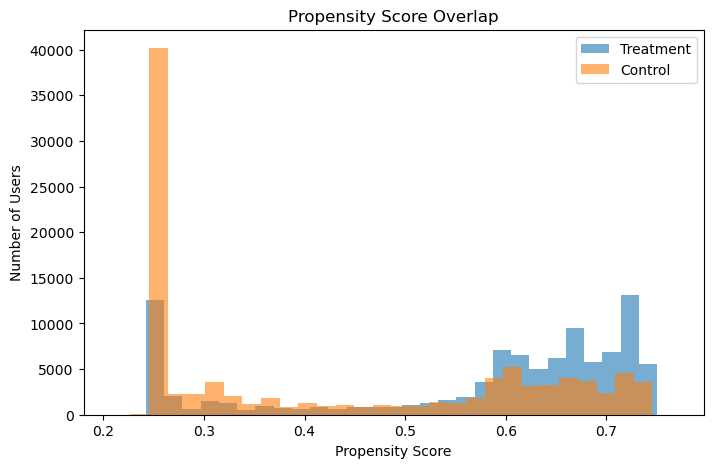

In [54]:
# Before applying PSM, we verify the common support assumption by checking 
# whether treated and control users have overlapping propensity score distributions.

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    observational_df.loc[observational_df["treatment"]==1, "propensity_score"],
    bins=30,
    alpha=0.6,
    label="Treatment"
)

plt.hist(
    observational_df.loc[observational_df["treatment"]==0, "propensity_score"],
    bins=30,
    alpha=0.6,
    label="Control"
)

plt.xlabel("Propensity Score")
plt.ylabel("Number of Users")
plt.title("Propensity Score Overlap")
plt.legend()

plt.show()

Inverse Probability of Treatment Weighting

In [52]:
# Calculate IPTW weights
observational_df["weight"] = np.where(
    observational_df["treatment"] == 1,
    1 / observational_df["propensity_score"],
    1 / (1 - observational_df["propensity_score"])
)

observational_df["weight"].describe()

count    200000.000000
mean          1.999974
std           0.835650
min           1.263207
25%           1.372087
50%           1.567286
75%           2.496206
max           4.464488
Name: weight, dtype: float64

In [55]:
# Weighted conversion rates
treated = observational_df["treatment"] == 1
control = observational_df["treatment"] == 0

iptw_treatment_rate = np.average(
    observational_df.loc[treated, "conversion"],
    weights=observational_df.loc[treated, "weight"]
)

iptw_control_rate = np.average(
    observational_df.loc[control, "conversion"],
    weights=observational_df.loc[control, "weight"]
)

iptw_effect = iptw_treatment_rate - iptw_control_rate

print(f"IPTW treatment conversion rate: {iptw_treatment_rate:.6f}")
print(f"IPTW control conversion rate:   {iptw_control_rate:.6f}")
print(f"IPTW treatment effect:          {iptw_effect:.6f}")

IPTW treatment conversion rate: 0.003116
IPTW control conversion rate:   0.003266
IPTW treatment effect:          -0.000150


Uplift Prediction

In [56]:
print(df.columns.tolist())

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']


In [57]:
print(df[["treatment", "conversion", "visit", "exposure"]].head(10))

   treatment  conversion  visit  exposure
0          0           0      0         0
1          1           0      0         0
2          1           0      0         0
3          1           0      0         0
4          1           0      0         0
5          1           0      0         0
6          1           0      0         0
7          1           0      0         0
8          1           0      0         0
9          1           0      0         0


In [58]:
from sklearn.model_selection import train_test_split

# Features
X = df[[f"f{i}" for i in range(12)]]

# Target
y = df["conversion"]

# Treatment indicator
t = df["treatment"]

# Split into treated and control datasets
X_treat = X[t == 1]
y_treat = y[t == 1]

X_control = X[t == 0]
y_control = y[t == 0]

print(f"Treated users: {len(X_treat)}")
print(f"Control users: {len(X_control)}")

Treated users: 169935
Control users: 30065


In [59]:
X_treat_train, X_treat_test, y_treat_train, y_treat_test = train_test_split(
    X_treat,
    y_treat,
    test_size=0.2,
    random_state=42
)

X_control_train, X_control_test, y_control_train, y_control_test = train_test_split(
    X_control,
    y_control,
    test_size=0.2,
    random_state=42
)

In [60]:
from sklearn.linear_model import LogisticRegression

# Treatment model
treatment_model = LogisticRegression(max_iter=1000)
treatment_model.fit(X_treat_train, y_treat_train)

# Control model
control_model = LogisticRegression(max_iter=1000)
control_model.fit(X_control_train, y_control_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [61]:
from sklearn.metrics import roc_auc_score

# Predicted probabilities
treat_probs = treatment_model.predict_proba(X_treat_test)[:, 1]
control_probs = control_model.predict_proba(X_control_test)[:, 1]

# ROC-AUC
treat_auc = roc_auc_score(y_treat_test, treat_probs)
control_auc = roc_auc_score(y_control_test, control_probs)

print(f"Treatment model ROC-AUC: {treat_auc:.3f}")
print(f"Control model ROC-AUC:   {control_auc:.3f}")

Treatment model ROC-AUC: 0.945
Control model ROC-AUC:   0.948


In [62]:
# Predict conversion probabilities for every user

X_all = df[[f"f{i}" for i in range(12)]]

df["p_treatment"] = treatment_model.predict_proba(X_all)[:, 1]
df["p_control"] = control_model.predict_proba(X_all)[:, 1]

# Individual predicted uplift
df["predicted_uplift"] = df["p_treatment"] - df["p_control"]

df[["p_treatment", "p_control", "predicted_uplift"]].head(10)

,p_treatment,p_control,predicted_uplift
0,0.001559,0.000238,0.001321
1,0.000362,0.000296,0.000066
2,0.000666,0.000319,0.000348
3,0.000633,0.000295,0.000338
4,0.000564,0.000249,0.000315
5,0.002365,0.001104,0.001261
6,0.000648,0.000308,0.000340
7,0.000454,0.000328,0.000126
8,0.004170,0.001753,0.002417
9,0.001221,0.000548,0.000673


In [63]:
# Create uplift deciles (10 groups)
df["uplift_decile"] = pd.qcut(
    df["predicted_uplift"],
    q=10,
    labels=False,
    duplicates="drop"
)

# Calculate observed treatment effect within each decile
uplift_validation = []

for decile in sorted(df["uplift_decile"].unique()):

    group = df[df["uplift_decile"] == decile]

    treat_rate = group.loc[group["treatment"] == 1, "conversion"].mean()
    control_rate = group.loc[group["treatment"] == 0, "conversion"].mean()

    uplift_validation.append({
        "Decile": decile,
        "Observed_Uplift": treat_rate - control_rate,
        "Treatment_Rate": treat_rate,
        "Control_Rate": control_rate
    })

uplift_validation = pd.DataFrame(uplift_validation)

uplift_validation

,Decile,Observed_Uplift,Treatment_Rate,Control_Rate
0,0,-0.000026,0.004996,0.005022
1,1,0.000236,0.000236,0.000000
2,2,0.000118,0.000118,0.000000
3,3,-0.000473,0.000177,0.000650
4,4,0.000118,0.000118,0.000000
5,5,-0.000596,0.000356,0.000952
6,6,-0.000102,0.000235,0.000337
7,7,0.000288,0.000944,0.000656
8,8,0.001835,0.002867,0.001032
9,9,0.014091,0.024243,0.010152


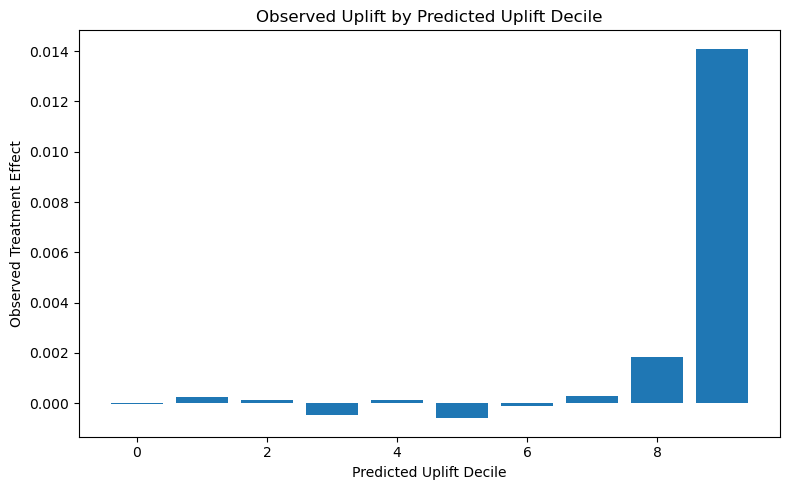

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    uplift_validation["Decile"],
    uplift_validation["Observed_Uplift"]
)

plt.xlabel("Predicted Uplift Decile")
plt.ylabel("Observed Treatment Effect")
plt.title("Observed Uplift by Predicted Uplift Decile")

plt.tight_layout()
plt.show()

In [66]:
positive_uplift = (df["predicted_uplift"] > 0).sum()

print(f"Users with positive predicted uplift: {positive_uplift}")
print(f"Percentage: {positive_uplift / len(df):.2%}")

Users with positive predicted uplift: 182848
Percentage: 91.42%


In [67]:
# Rank users from highest to lowest predicted uplift
df_sorted = df.sort_values("predicted_uplift", ascending=False)

# Top 10% and Top 20%
top10 = df_sorted.head(int(0.10 * len(df)))
top20 = df_sorted.head(int(0.20 * len(df)))

print(f"Top 10% users: {len(top10)}")
print(f"Top 20% users: {len(top20)}")

Top 10% users: 20000
Top 20% users: 40000


In [68]:
# Average predicted uplift for each strategy
positive_avg = df.loc[df["predicted_uplift"] > 0, "predicted_uplift"].mean()
top20_avg = top20["predicted_uplift"].mean()
top10_avg = top10["predicted_uplift"].mean()

print(f"Average uplift (Positive): {positive_avg:.6f}")
print(f"Average uplift (Top 20%):  {top20_avg:.6f}")
print(f"Average uplift (Top 10%):  {top10_avg:.6f}")

Average uplift (Positive): 0.001525
Average uplift (Top 20%):  0.005956
Average uplift (Top 10%):  0.010827


In [69]:
# Business assumptions
revenue_per_conversion = 100
ad_cost_per_user = 0.05

strategies = {
    "Positive Uplift": (positive_avg, positive_uplift),
    "Top 20%": (top20_avg, len(top20)),
    "Top 10%": (top10_avg, len(top10))
}

results = []

for name, (avg_uplift, users) in strategies.items():

    expected_extra_conversions = avg_uplift * users
    expected_revenue = expected_extra_conversions * revenue_per_conversion
    advertising_cost = users * ad_cost_per_user
    expected_profit = expected_revenue - advertising_cost

    results.append({
        "Strategy": name,
        "Users_Targeted": users,
        "Avg_Uplift": avg_uplift,
        "Expected_Extra_Conversions": expected_extra_conversions,
        "Expected_Revenue": expected_revenue,
        "Advertising_Cost": advertising_cost,
        "Expected_Profit": expected_profit
    })

business_results = pd.DataFrame(results)

business_results

,Strategy,Users_Targeted,Avg_Uplift,Expected_Extra_Conversions,Expected_Revenue,Advertising_Cost,Expected_Profit
0,Positive Uplift,182848,0.001525,278.771904,27877.190413,9142.4,18734.790413
1,Top 20%,40000,0.005956,238.236031,23823.603140,2000.0,21823.603140
2,Top 10%,20000,0.010827,216.534981,21653.498065,1000.0,20653.498065


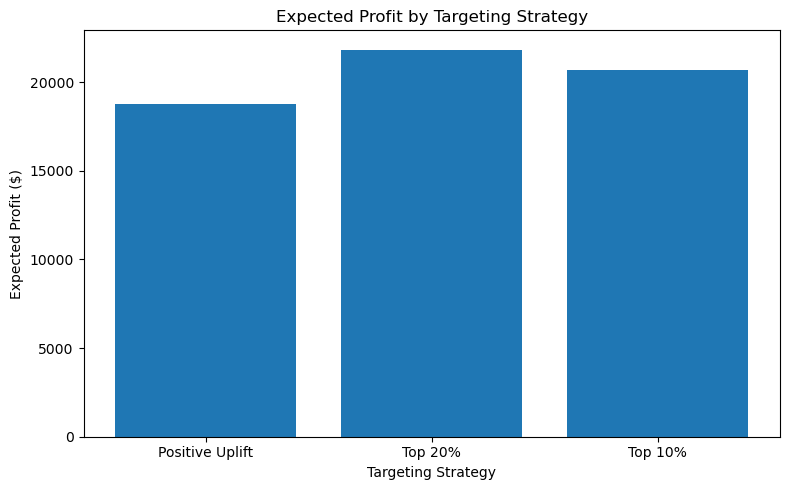

In [70]:
plt.figure(figsize=(8,5))

plt.bar(
    business_results["Strategy"],
    business_results["Expected_Profit"]
)

plt.title("Expected Profit by Targeting Strategy")
plt.xlabel("Targeting Strategy")
plt.ylabel("Expected Profit ($)")

plt.tight_layout()
plt.show()